# Mathematical Formulation and Trade-offs in Learning-Augmented Routing

## tl;dr

This notebook explains what the routing algorithm optimizes, what is imposed structurally, and what is actually learned.

Three conclusions matter:

1. The method is a greedy bi-criteria heuristic, not a globally optimal vehicle-routing solver. At each decision it balances normalized directed travel time against a smoothed pairwise zone-order penalty.
2. Zero zone re-entry is produced by the zone-exhaustion construction. Learning decides the order of zone blocks; it does not create contiguity by itself.
3. The empirical trade-off is non-monotone. Validation score improves through preference weight \(w=2\), while \(w=4\) and \(w=8\) increase travel cost and worsen official score. Stronger imitation is therefore not automatically better.

The purpose is pedagogical: connect the implementation to an explicit objective, inspect limiting cases on a toy directed graph, and then reconcile those mechanisms with the committed validation and test results.

## Context & Methods

### Graph and route representation

For one route, let \(G=(V,A)\) be a complete directed graph. The station is \(v_0\), each remaining vertex is a delivery stop, and \(d_{ij}\geq 0\) is the supplied directed travel time from stop \(i\) to stop \(j\). Each delivery stop belongs to one zone \(z(i)\).

A feasible sequence is a permutation

\[
\pi=(v_0,v_1,\ldots,v_n)
\]

that starts at the station and visits every delivery stop exactly once. The implemented path cost is

\[
C(\pi)=\sum_{t=0}^{n-1} d_{v_t,v_{t+1}},
\]

with no automatic return-to-station edge.

### Learned pairwise preference

For station \(s\) and two zones \(a,b\), training routes provide counts \(N_s(a\prec b)\) and \(N_s(b\prec a)\). With Laplace smoothing \(\alpha>0\),

\[
\widehat p_s(a\prec b)
=
\frac{N_s(a\prec b)+\alpha}
     {N_s(a\prec b)+N_s(b\prec a)+2\alpha}.
\]

When an exact station-zone pair has insufficient support, the estimator backs off to station-level parent zones, then global parent zones, and finally the neutral probability \(0.5\). This hierarchy is an interpretable regularizer rather than a black-box prediction layer.

### Greedy learning-augmented decision

Suppose the current stop is \(i\) and the unvisited zone set is \(R\). For candidate zone \(q\in R\), define

\[
T(q\mid i)
=
\frac{\min_{j:z(j)=q}d_{ij}}
     {\operatorname{median}_{r\in R}\min_{j:z(j)=r}d_{ij}}
\]

and the Borda-style preference penalty

\[
B(q\mid R)
=
1-\frac{1}{|R|-1}\sum_{r\in R\setminus\{q\}}\widehat p_s(q\prec r).
\]

The next zone is selected greedily:

\[
q^\star
=
\arg\min_{q\in R}
\left\{
T(q\mid i)+wB(q\mid R)
\right\}.
\]

All stops in \(q^\star\) are then exhausted by within-zone nearest neighbour before another zone is selected.

### Key assumptions and boundaries

- The algorithm is greedy; it does not minimize one global route objective exactly.
- Historical precedence is treated as useful behavioral signal, not proof of optimal driver preference.
- \(w=0\) is a zone-contiguous distance heuristic, not the stop-level nearest-neighbour baseline.
- Zone exhaustion makes re-entry zero whenever each stop has one fixed zone label.
- The naive pairwise scoring loop is \(O(m^3)\) in the number of zones \(m\); within-zone nearest-neighbour construction is at most \(O(n^2)\) in stops.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").exists()
    and (candidate / "src" / "lastmile").exists()
)
OUT = ROOT / "artifacts" / "research_story"
OUT.mkdir(parents=True, exist_ok=True)

BLUE = "#2F6BFF"
GOLD = "#D69E00"
INK = "#202733"
GREY = "#A9B0BA"
LIGHT_BLUE = "#C7D8FF"
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.edgecolor": INK,
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
})

## Results

### 1. A toy directed graph makes the trade-off visible

The cell below deliberately keeps the full optimization logic in the notebook. Four delivery zones have directed travel costs and a learned precedence matrix. Distance initially favors zone A, while the learned ordering favors B before A. Varying \(w\) reveals the threshold at which behavioral preference changes the route.

In [2]:
zones = ("A", "B", "C", "D")
travel = {
    "S": {"A": 1.00, "B": 1.10, "C": 1.40, "D": 1.60},
    "A": {"B": 1.00, "C": 2.20, "D": 2.00},
    "B": {"A": 1.00, "C": 1.00, "D": 1.50},
    "C": {"A": 1.30, "B": 1.00, "D": 0.90},
    "D": {"A": 1.00, "B": 1.20, "C": 0.80},
}

declared_probability = {
    ("A", "B"): 0.20,
    ("A", "C"): 0.80,
    ("A", "D"): 0.75,
    ("B", "C"): 0.85,
    ("B", "D"): 0.80,
    ("C", "D"): 0.70,
}


def probability_before(first: str, second: str) -> float:
    if first == second:
        return 0.5
    if (first, second) in declared_probability:
        return declared_probability[(first, second)]
    return 1.0 - declared_probability[(second, first)]


def preference_penalty(zone: str, remaining: set[str]) -> float:
    others = remaining - {zone}
    if not others:
        return 0.0
    strength = np.mean([probability_before(zone, other) for other in others])
    return float(1.0 - strength)


def greedy_zone_sequence(weight: float) -> tuple[str, ...]:
    current = "S"
    remaining = set(zones)
    sequence = ["S"]
    while remaining:
        distances = {zone: travel[current][zone] for zone in remaining}
        scale = float(np.median(list(distances.values()))) or 1.0

        def decision_score(zone: str) -> tuple[float, str]:
            travel_term = distances[zone] / scale
            preference_term = preference_penalty(zone, remaining)
            return travel_term + weight * preference_term, zone

        selected = min(remaining, key=decision_score)
        sequence.append(selected)
        remaining.remove(selected)
        current = selected
    return tuple(sequence)


def path_cost(sequence: tuple[str, ...]) -> float:
    return float(sum(travel[a][b] for a, b in zip(sequence, sequence[1:])))


def ordering_disagreement(sequence: tuple[str, ...]) -> float:
    ordered = sequence[1:]
    penalties = [
        1.0 - probability_before(first, second)
        for first, second in combinations(ordered, 2)
    ]
    return float(np.mean(penalties))


toy_rows = []
for weight in (0.0, 0.25, 0.5, 1.0, 2.0, 4.0):
    sequence = greedy_zone_sequence(weight)
    toy_rows.append({
        "preference_weight": weight,
        "zone_sequence": " → ".join(sequence),
        "path_cost": path_cost(sequence),
        "preference_inconsistency": ordering_disagreement(sequence),
    })

toy = pd.DataFrame(toy_rows)
toy["travel_increase_vs_w0"] = toy["path_cost"] / toy.loc[0, "path_cost"] - 1
toy.to_csv(OUT / "toy_tradeoff.csv", index=False)
display(toy.round(3))

,preference_weight,zone_sequence,path_cost,preference_inconsistency,travel_increase_vs_w0
0,0.00,S → A → B → C → D,3.9,0.317,0.000
1,0.25,S → A → B → C → D,3.9,0.317,0.000
2,0.50,S → B → A → C → D,5.2,0.217,0.333
3,1.00,S → B → A → C → D,5.2,0.217,0.333
4,2.00,S → B → A → C → D,5.2,0.217,0.333
5,4.00,S → B → A → C → D,5.2,0.217,0.333


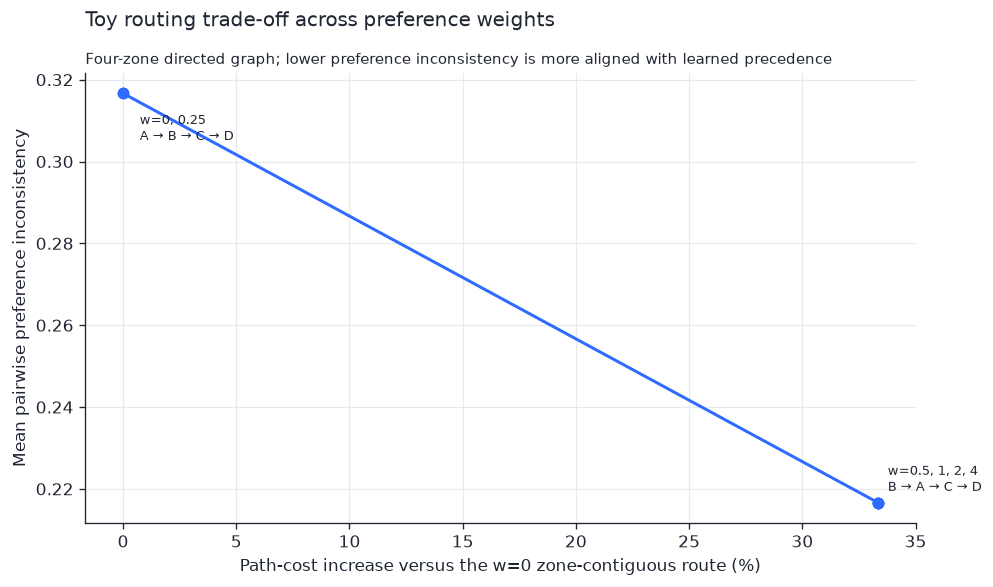

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.plot(
    100 * toy["travel_increase_vs_w0"],
    toy["preference_inconsistency"],
    color=BLUE,
    marker="o",
    linewidth=1.8,
)
for _, group in toy.groupby(
    ["travel_increase_vs_w0", "preference_inconsistency", "zone_sequence"],
    sort=True,
):
    first = group.iloc[0]
    weights = ", ".join(f"{value:g}" for value in group["preference_weight"])
    ax.annotate(
        f"w={weights}\n{first['zone_sequence'].replace('S → ', '')}",
        (
            100 * first["travel_increase_vs_w0"],
            first["preference_inconsistency"],
        ),
        xytext=(10, -28) if first["travel_increase_vs_w0"] == 0 else (6, 7),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_title("Toy routing trade-off across preference weights", loc="left", pad=28)
ax.text(
    0,
    1.02,
    "Four-zone directed graph; lower preference inconsistency is more aligned with learned precedence",
    transform=ax.transAxes,
    fontsize=9,
)
ax.set_xlabel("Path-cost increase versus the w=0 zone-contiguous route (%)")
ax.set_ylabel("Mean pairwise preference inconsistency")
ax.grid(color="#E6E9EE", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "toy_tradeoff.png", bbox_inches="tight")
plt.show()

The toy example exposes a threshold effect: small preference weights leave the travel-led zone order unchanged; after the learned penalty becomes large enough, B moves before A. The route can become more consistent with learned precedence at additional travel cost. This is a mechanism illustration, not evidence about Amazon routes.

### 2. The empirical validation frontier is non-monotone

A validation setting is Pareto dominated when another declared weight has no higher median travel-time increase and no higher median official score, with at least one strict improvement. Because both axes are minimized, dominated settings have no empirical justification under these two criteria.

In [4]:
validation = pd.read_csv(
    ROOT / "artifacts" / "confirmatory_results" / "validation_tradeoff.csv"
).sort_values("preference_weight")


def is_dominated(row: pd.Series, frame: pd.DataFrame) -> bool:
    weakly_better = (
        (frame["median_travel_time_increase_fraction"]
         <= row["median_travel_time_increase_fraction"])
        & (frame["median_official_score"] <= row["median_official_score"])
    )
    strictly_better = (
        (frame["median_travel_time_increase_fraction"]
         < row["median_travel_time_increase_fraction"])
        | (frame["median_official_score"] < row["median_official_score"])
    )
    return bool((weakly_better & strictly_better).any())


validation["pareto_dominated"] = [
    is_dominated(row, validation) for _, row in validation.iterrows()
]
validation["inside_5pct_guardrail"] = (
    validation["median_travel_time_increase_fraction"] <= 0.05
)
validation.to_csv(OUT / "empirical_pareto_frontier.csv", index=False)
display(
    validation[[
        "preference_weight",
        "median_travel_time_increase_fraction",
        "median_official_score",
        "median_pairwise_disagreement",
        "inside_5pct_guardrail",
        "pareto_dominated",
    ]].round(5)
)

,preference_weight,median_travel_time_increase_fraction,median_official_score,median_pairwise_disagreement,inside_5pct_guardrail,pareto_dominated
0,0.00,0.02491,0.06721,0.50594,True,False
1,0.25,0.02654,0.06688,0.43850,True,False
2,0.50,0.03258,0.06572,0.40230,True,False
3,1.00,0.03714,0.06288,0.37782,True,False
4,2.00,0.04535,0.06129,0.35786,True,False
5,4.00,0.05612,0.06316,0.34378,False,True
6,8.00,0.06449,0.06528,0.33760,False,True


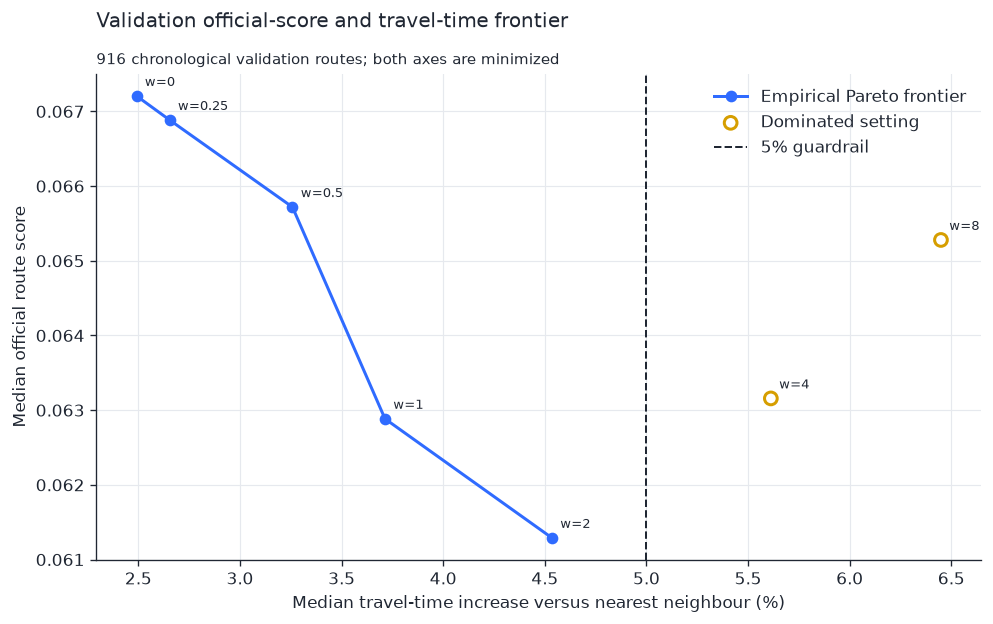

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 5.3))
frontier = validation.loc[~validation["pareto_dominated"]].sort_values(
    "median_travel_time_increase_fraction"
)
dominated = validation.loc[validation["pareto_dominated"]]

ax.plot(
    100 * frontier["median_travel_time_increase_fraction"],
    frontier["median_official_score"],
    color=BLUE,
    marker="o",
    linewidth=1.8,
    label="Empirical Pareto frontier",
)
ax.scatter(
    100 * dominated["median_travel_time_increase_fraction"],
    dominated["median_official_score"],
    s=58,
    facecolors="none",
    edgecolors=GOLD,
    linewidths=1.8,
    label="Dominated setting",
)
for row in validation.itertuples():
    ax.annotate(
        f"w={row.preference_weight:g}",
        (
            100 * row.median_travel_time_increase_fraction,
            row.median_official_score,
        ),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=8,
    )
ax.axvline(5, color=INK, linestyle="--", linewidth=1.2, label="5% guardrail")
ax.set_title("Validation official-score and travel-time frontier", loc="left", pad=28)
ax.text(
    0,
    1.02,
    "916 chronological validation routes; both axes are minimized",
    transform=ax.transAxes,
    fontsize=9,
)
ax.set_xlabel("Median travel-time increase versus nearest neighbour (%)")
ax.set_ylabel("Median official route score")
ax.grid(color="#E6E9EE", linewidth=0.7)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "empirical_pareto_frontier.png", bbox_inches="tight")
plt.show()

Weights 4 and 8 are dominated by weight 2: they cost more travel time and have worse official score. This is an empirical over-regularization pattern. Preference disagreement continues to fall, but excessive imitation weight harms the composite challenge score.

### 3. Ablation separates zone contiguity from learned ordering

Nearest neighbour operates at stop level and can re-enter zones. Angular sweep and pairwise-zone routing both exhaust a selected zone before moving on, so both obtain zero median re-entry. Their official scores differ sharply; that difference is evidence about zone ordering, not merely contiguity.

In [6]:
methods = pd.read_csv(
    ROOT / "artifacts" / "confirmatory_results" / "test_method_summary.csv"
).set_index("method")
algorithmic = methods.loc[
    ["nearest_neighbor", "angular_zone", "pairwise_zone"]
].copy()
algorithmic["travel_time_ratio_vs_nn"] = (
    algorithmic["travel_time_seconds_median"]
    / algorithmic.loc["nearest_neighbor", "travel_time_seconds_median"]
)
algorithmic["score_reduction_vs_nn"] = (
    1
    - algorithmic["official_score_median"]
    / algorithmic.loc["nearest_neighbor", "official_score_median"]
)
display(algorithmic.round(4))

,routes,official_score_median,official_score_mean,pairwise_disagreement_median,travel_time_seconds_median,zone_reentries_median,runtime_ms_median,travel_time_ratio_vs_nn,score_reduction_vs_nn
method,,,,,,,,,
nearest_neighbor,926,0.1011,0.1160,0.4953,11188.80,21.0,1.3563,1.0000,0.0000
angular_zone,926,0.0978,0.1033,0.5063,13021.45,0.0,0.2818,1.1638,0.0328
pairwise_zone,926,0.0607,0.0679,0.3343,11740.00,0.0,2.2703,1.0493,0.3995


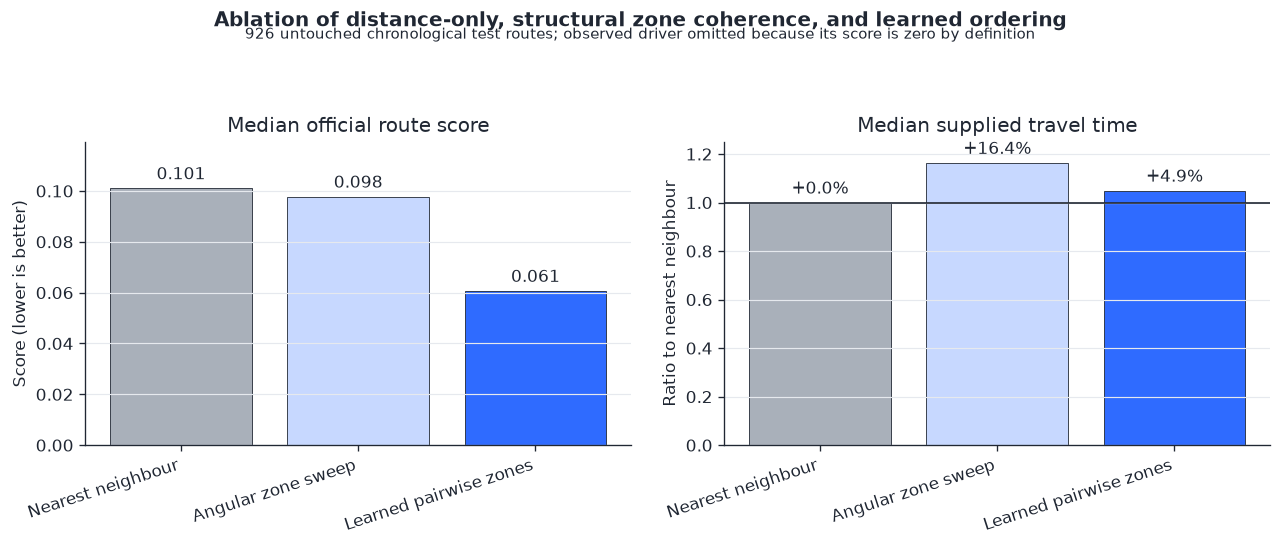

In [7]:
labels = ["Nearest neighbour", "Angular zone sweep", "Learned pairwise zones"]
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.6))

score_bars = axes[0].bar(
    x,
    algorithmic["official_score_median"],
    color=[GREY, LIGHT_BLUE, BLUE],
    edgecolor=INK,
    linewidth=0.5,
)
axes[0].bar_label(score_bars, fmt="%.3f", padding=3)
axes[0].set_title("Median official route score")
axes[0].set_ylabel("Score (lower is better)")
axes[0].set_xticks(x, labels, rotation=18, ha="right")
axes[0].set_ylim(0, 1.18 * algorithmic["official_score_median"].max())

time_bars = axes[1].bar(
    x,
    algorithmic["travel_time_ratio_vs_nn"],
    color=[GREY, LIGHT_BLUE, BLUE],
    edgecolor=INK,
    linewidth=0.5,
)
axes[1].bar_label(
    time_bars,
    labels=[f"{100 * (value - 1):+.1f}%" for value in algorithmic["travel_time_ratio_vs_nn"]],
    padding=3,
)
axes[1].axhline(1, color=INK, linewidth=1)
axes[1].set_title("Median supplied travel time")
axes[1].set_ylabel("Ratio to nearest neighbour")
axes[1].set_xticks(x, labels, rotation=18, ha="right")
axes[1].set_ylim(0, 1.25)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E6E9EE", linewidth=0.7)
fig.suptitle(
    "Ablation of distance-only, structural zone coherence, and learned ordering",
    fontweight="bold",
)
fig.text(
    0.5,
    0.93,
    "926 untouched chronological test routes; observed driver omitted because its score is zero by definition",
    ha="center",
    fontsize=9,
)
fig.tight_layout(rect=(0, 0, 1, 0.89))
fig.savefig(OUT / "method_ablation.png", bbox_inches="tight")
plt.show()

The angular baseline demonstrates that zone contiguity alone is insufficient: it removes re-entry but has only a small official-score advantage over nearest neighbour and a much larger median travel-time cost. The learned pairwise ordering produces the strongest official-score reduction with substantially less travel inflation.

## Takeaways

- The project studies a constrained behavioral-imitation trade-off, not pure shortest-path optimization.
- \(w\) controls the local exchange rate between normalized travel time and learned precedence inconsistency.
- The benefit of learning is best isolated against another zone-contiguous method, not only against stop-level nearest neighbour.
- Zone re-entry reduction should be attributed to the zone-exhaustion constraint.
- Weight 2 lies inside the predeclared validation guardrail and on the empirical frontier; weights 4 and 8 illustrate diminishing returns and over-regularization.
- The untouched test result remains confirmatory, while the mathematical and validation analyses explain why that result is plausible.

## Limitations and research extensions

- The local greedy rule has no global optimality guarantee.
- Learned pairwise probabilities may be non-transitive and are aggregated with a Borda-style score.
- A future formulation could optimize a global mixed-integer objective with time windows and compare its Pareto frontier against the greedy heuristic.
- Robust preference optimization could account explicitly for uncertainty in sparse zone-pair estimates.
- A prospective study would be required to determine whether driver-like sequencing improves workload, safety, or delivery outcomes.